# Quick start

- A default `DarkEmulator2` instance and its basic settings.
- Fiducial parameters and native allowed ranges.
- Linear and non-linear matter P(k) from the public API.

## Imports

- Packages used in this notebook.

In [1]:
import pprint
import numpy as np
import matplotlib.pyplot as plt
from dark_emulator2 import DarkEmulator2 as dq2

## Create an emulator

- Default settings are used unless keyword options are passed to `DarkEmulator2()`.

In [2]:
emu = dq2()

## Default settings

- The emulator configuration is stored in `obj.setting`.

In [3]:
emu.show_mode()

npart(1D) :: 3000
lbox :: 1000 [Mpc/h]
Nyquist frequency is 9.4248 [h/Mpc].
Shotnoise limit is 0.0370  [(Mpc/h)^3].
lin_pk_switch :: True
lin_pk_switch_k :: 0.01 [h/Mpc]
pk-nsmooth :: 20
reduce_shotnoise :: False


## Fiducial parameters and ranges

- `get_fid_param()` returns a complete fiducial dictionary.
- `get_param_range()` returns the native DQ2 allowed ranges.
- Valid input combinations are covered in `02_cosmological_parameter`.

In [4]:
p = emu.param.get_fid_param()
p_range = emu.param.get_param_range()

print("fiducial parameters")
pprint.pprint(p)
print("\nparameter range")
pprint.pprint(p_range)

fiducial parameters
{'As': 2.206516233894705e-09,
 'Mnu': 0.06,
 'Omega_de': 0.68434,
 'Omega_k': 0.0,
 'Omega_m': 0.3156,
 'h0': 0.6723473803969963,
 'ln(10^10As)': 3.094,
 'ns': 0.9645,
 'omega_b': 0.02225,
 'omega_cdm': 0.1198,
 'sigma8': 0.831,
 'w0': -1,
 'wa': 0}
parameter range
{'As': [2.832614112620091e-10, 3.1570240072959045e-08],
 'Mnu': [0.0, 0.5],
 'Omega_de': [0.4125, 0.938542],
 'Omega_k': [-0.1, 0.1],
 'Omega_m': [0.05, 0.62],
 'S8': [0.6, 0.95],
 'dist': [0.0, 5.0],
 'h0': [0.5, 0.9],
 'ln(10^10As)': [1.0412, 5.7548],
 'ns': [0.916275, 1.012725],
 'omega_b': [0.015, 0.03],
 'omega_cdm': [0.01, 0.3],
 'sigma8': [0.42, 1.3],
 'w': [-1.5, -0.5],
 'w0': [-1.5, -0.5],
 'wa': [-0.5, 0.5]}


## Linear and non-linear P(k)

- CDM+baryon P(k) at `z=0` on the default k grid.

- Linear and non-linear CDM+baryon matter P(k).

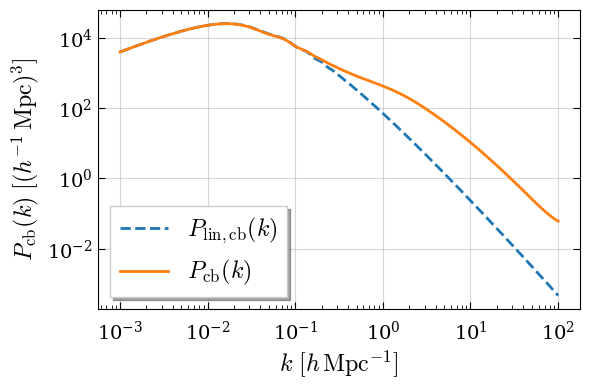

In [5]:
k, pk = emu.get_pk(p)
lin_k, lin_pk = emu.get_lin_pk(p)

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k, lin_pk, "--", lw=2, label=r"$P_\mathrm{lin,cb}(k)$")
plt.plot(k, pk, "-", lw=2, label=r"$P_\mathrm{cb}(k)$")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P_\mathrm{cb}(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

- Linear and non-linear total matter P(k).

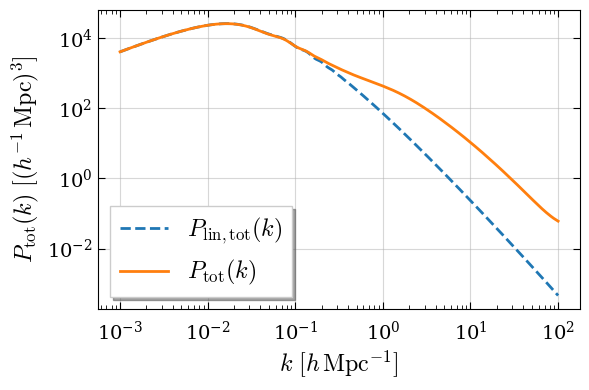

In [6]:
k, pk = emu.get_pk_total(p)
lin_k, lin_pk = emu.get_lin_pk_total(p)

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k, lin_pk, "--", lw=2, label=r"$P_\mathrm{lin,tot}(k)$")
plt.plot(k, pk, "-", lw=2, label=r"$P_\mathrm{tot}(k)$")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P_\mathrm{tot}(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## Custom k grid

- `klist` evaluates spectra on a user-specified k grid.

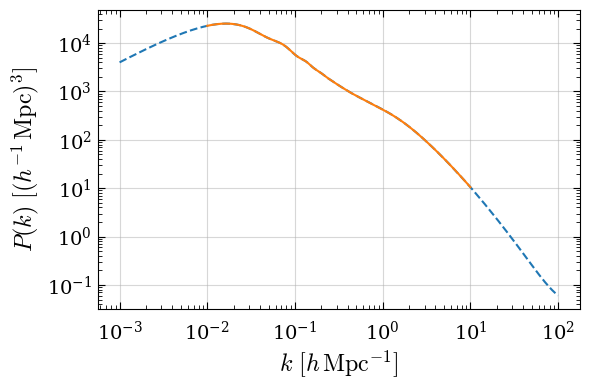

In [7]:
def_k, def_pk = emu.get_pk_total(p)

new_klist = np.logspace(-2,1,1000)
k, pk = emu.get_pk_total(p, klist=new_klist)

fig = plt.figure(figsize=(6, 4))
plt.plot(def_k, def_pk, "--")
plt.plot(k, pk, "-")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## Custom redshifts

- `zred` evaluates one redshift at a time.

- The resulting spectra can be compared across redshifts.

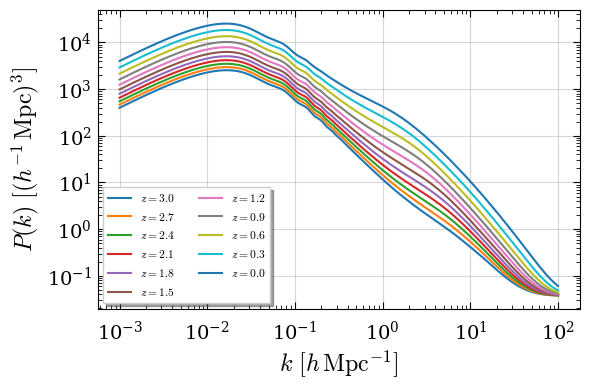

In [8]:
zlist = np.linspace(3,0,11)
fig = plt.figure(figsize=(6, 4))
for z in zlist :
  k, pk = emu.get_pk_total(p, zred=z)
  plt.plot(k, pk, "-", label=rf"$z={z:.1f}$")
plt.legend(ncol=2,fontsize="small")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")

plt.tight_layout()
plt.show()

## Linear P(k) method

- `method="emulator"` is the default and fast.
- `method="class"` runs CLASS and is slower.

- Emulator-based and CLASS-based linear inputs are compared through the same non-linear P(k) call.

CPU times: user 31.3 ms, sys: 0 ns, total: 31.3 ms
Wall time: 16.9 ms
CPU times: user 1min 17s, sys: 5.75 s, total: 1min 23s
Wall time: 10.1 s


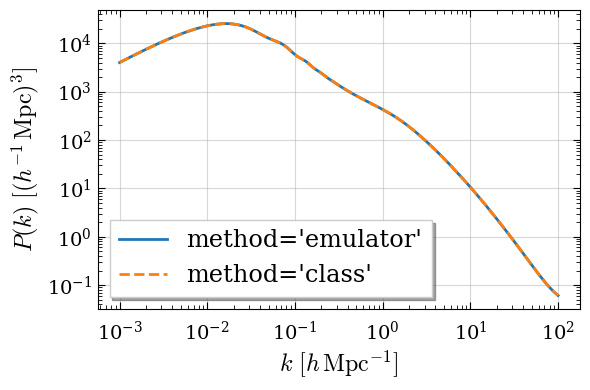

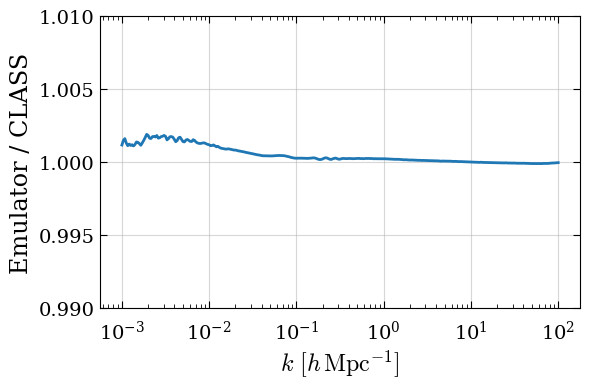

In [9]:
p = emu.param.get_fid_param()

%time k_emu, pk_emu = emu.get_pk(p, method="emulator") # default
%time k_class, pk_class = emu.get_pk(p, method="class") # use linear boltzmann code CLASS

fig = plt.figure(figsize=(6, 4))
plt.plot(k_emu, pk_emu, "-", lw=2, label="method='emulator'")
plt.plot(k_class, pk_class, "--", lw=2, label="method='class'")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(k_emu, pk_emu/pk_class, "-", lw=2)
plt.xscale("log")
plt.yscale("linear")
plt.ylim(0.99,1.01)
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel("Emulator / CLASS", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

- The same `method` option is available for the linear P(k) API.

CPU times: user 14.2 ms, sys: 6.58 ms, total: 20.8 ms
Wall time: 8.17 ms
CPU times: user 1.88 ms, sys: 134 μs, total: 2.01 ms
Wall time: 1.44 ms


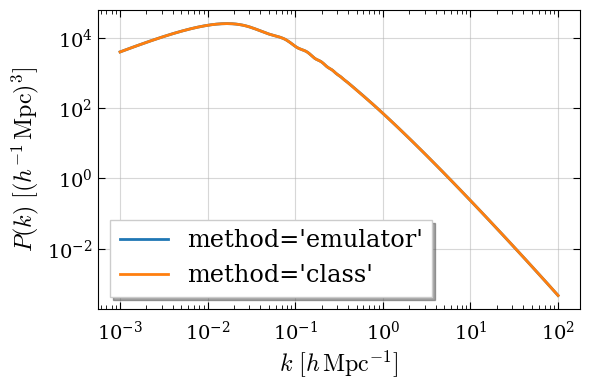

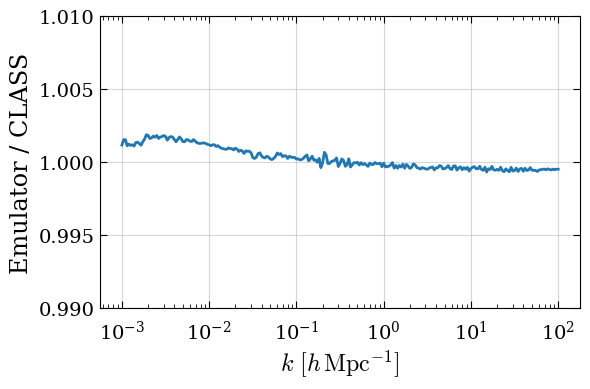

In [10]:
p = emu.param.get_fid_param()

%time lin_k_emu, lin_pk_emu = emu.get_lin_pk(p, method="emulator") # default
%time lin_k_class, lin_pk_class = emu.get_lin_pk(p, klist=lin_k_emu, method="class") # use linear boltzmann code CLASS

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k_emu, lin_pk_emu, "-", lw=2, label="method='emulator'")
plt.plot(lin_k_class, lin_pk_class, "-", lw=2, label="method='class'")
plt.legend(fontsize="xx-large")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel(r"$P(k) \,\, [(h^{-1}\, \mathrm{Mpc})^3]$", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(6, 4))
plt.plot(lin_k_emu, lin_pk_emu/lin_pk_class, "-", lw=2)
plt.xscale("log")
plt.yscale("linear")
plt.ylim(0.99,1.01)
plt.xlabel(r"$k \,\, [h\, \mathrm{Mpc}^{-1}]$", fontsize="xx-large")
plt.ylabel("Emulator / CLASS", fontsize="xx-large")
plt.grid(True, axis="both", which="major")
plt.tight_layout()
plt.show()

## Aliases

- These convenience methods call the same underlying API.

```python
def get_lin_pk_cb(param, zred, klist=None, method="emulator")
def get_lin_pk(param, zred, klist=None, method="emulator", pk_type="cb")


def get_lin_pk_total(param, zred, klist=None, method="emulator")
def get_lin_pk(param, zred, klist=None, method="emulator", pk_type="total")


def get_pk_cb(param, zred, klist=None, method="emulator")
def get_pk(param, zred, klist=None, method="emulator", pk_type="cb")


def get_pk_total(param, zred, klist=None, method="emulator")
def get_pk(param, zred, klist=None, method="emulator", pk_type="total")
```